In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import os

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Data import and initial processing

In [27]:
base_path = '/content/drive/MyDrive/paml_final'

In [28]:
train_path = os.path.join(base_path, 'NBA_Train.csv')
val_path = os.path.join(base_path, 'NBA_Validation.csv')
test_path = os.path.join(base_path, 'NBA_Test.csv')

In [29]:
try:
    df_train = pd.read_csv(train_path)
    df_val = pd.read_csv(val_path)
    # df_test = pd.read_csv(test_path)

    print(f"train data rows: {len(df_train)}")
    print(f"valid data rows: {len(df_val)}")

    display(df_train.head())

except FileNotFoundError:
    print(f"Check again path: {train_path}")

train data rows: 16846
valid data rows: 3643


,player_name,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,...,pts,role,draft_status,yr_num,ht_inches,Playmaker_Usg,Scoring_Gravity,AST_to_USG,Elite_Recruit,Freshman_Star
0,Jesus Verdejo,South Florida,BE,27,72.0,96.2,21.8,45.7,47.98,2.1,...,12.1852,Unknown,0,4.0,76.0,320.46,261.98180,0.674281,0,0
1,Mike Hornbuckle,Pepperdine,WCC,30,44.5,97.7,16.0,53.6,53.69,4.1,...,4.9333,Unknown,0,4.0,76.0,219.20,106.55928,0.856196,0,0
2,Anthony Brown,Pacific,BW,33,56.2,96.5,22.0,52.8,54.31,8.3,...,7.5758,Unknown,0,4.0,80.0,180.40,490.91184,0.372710,0,0
3,Justin Drummond,Wagner,NEC,30,82.8,99.7,20.5,48.8,53.07,2.9,...,10.5000,Unknown,0,4.0,78.0,522.75,467.25000,1.243842,0,0
4,Jamal Smith,Wagner,NEC,30,80.4,92.5,23.0,43.5,45.29,6.4,...,11.8667,Unknown,0,4.0,77.0,273.70,423.64119,0.517369,1,0


In [30]:
status_map = {0: 'Undrafted', 1: '1st Round', 2: '2nd Round'}
df_train['draft_label'] = df_train['draft_status'].map(status_map)
df_val['draft_label'] = df_val['draft_status'].map(status_map)

In [31]:
df_train['split'] = 'Train (2009-2018)'
df_val['split'] = 'Validation (2019-2020)'
df_combined = pd.concat([df_train, df_val])

# Class Imbalance Analysis

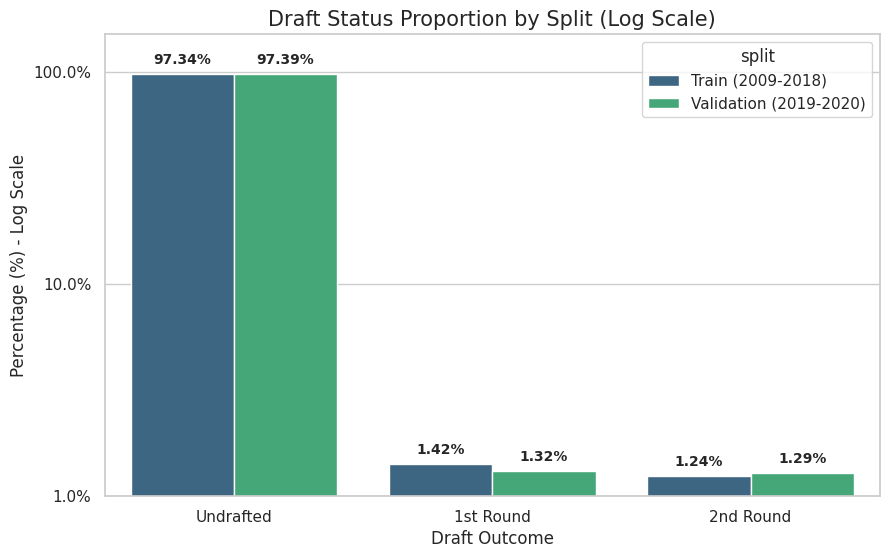

In [32]:
df_combined_clean = df_combined.replace([np.inf, -np.inf], np.nan).fillna(0)

dist_df = df_combined_clean.groupby(['split', 'draft_label']).size().reset_index(name='count')
totals = df_combined_clean.groupby('split').size().to_dict()
dist_df['percentage'] = dist_df.apply(lambda x: (x['count'] / totals[x['split']]) * 100, axis=1)

plt.figure(figsize=(10, 6))
order_list = ['Undrafted', '1st Round', '2nd Round']


ax = sns.barplot(data=dist_df, x='draft_label', y='percentage', hue='split',
                 order=order_list, palette='viridis')

ax.set_yscale("log")

plt.title('Draft Status Proportion by Split (Log Scale)', fontsize=15)
plt.ylabel('Percentage (%) - Log Scale')
plt.xlabel('Draft Outcome')

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}%',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.ylim(top=150)
plt.show()

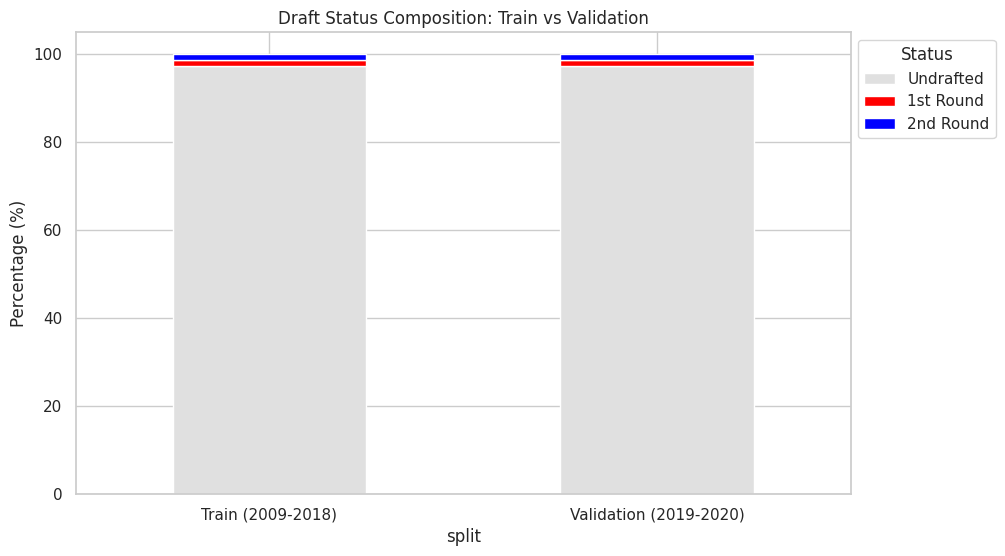

In [33]:
ct = pd.crosstab(df_combined['split'], df_combined['draft_label'], normalize='index') * 100
ct = ct[order_list]

ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#E0E0E0', '#FF0000', '#0000FF'])
plt.title('Draft Status Composition: Train vs Validation')
plt.ylabel('Percentage (%)')
plt.legend(title='Status', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

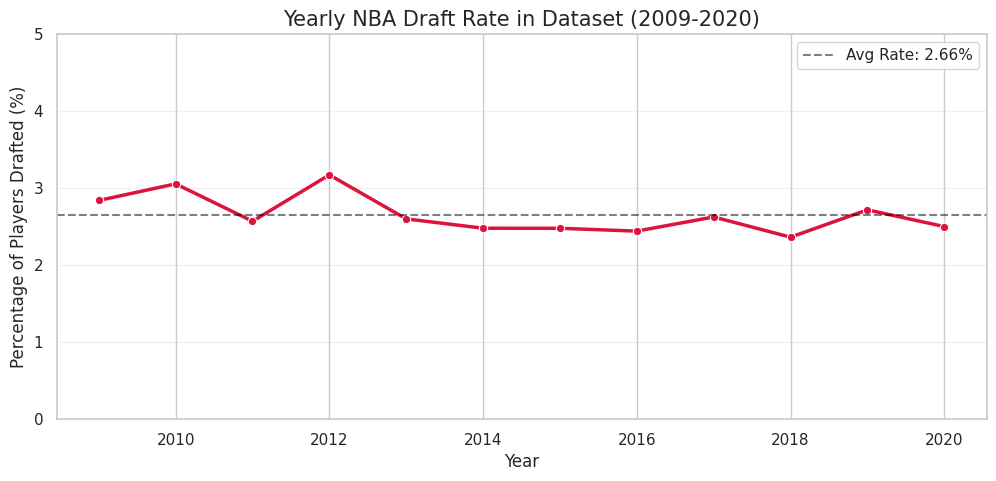

In [34]:
yearly_rate = df_combined.groupby('year')['draft_status'].apply(lambda x: (x > 0).mean() * 100).reset_index()
yearly_rate.columns = ['Year', 'Draft_Rate']

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_rate, x='Year', y='Draft_Rate', marker='o', color='crimson', linewidth=2.5)


avg_rate = yearly_rate['Draft_Rate'].mean()
plt.axhline(avg_rate, color='black', linestyle='--', alpha=0.5, label=f'Avg Rate: {avg_rate:.2f}%')

plt.title('Yearly NBA Draft Rate in Dataset (2009-2020)', fontsize=15)
plt.ylabel('Percentage of Players Drafted (%)')
plt.xlabel('Year')
plt.ylim(0, 5)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Feature Engineering Check

/tmp/ipykernel_10722/2481898393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='draft_label', y=feature,
/tmp/ipykernel_10722/2481898393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='draft_label', y=feature,
/tmp/ipykernel_10722/2481898393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='draft_label', y=feature,


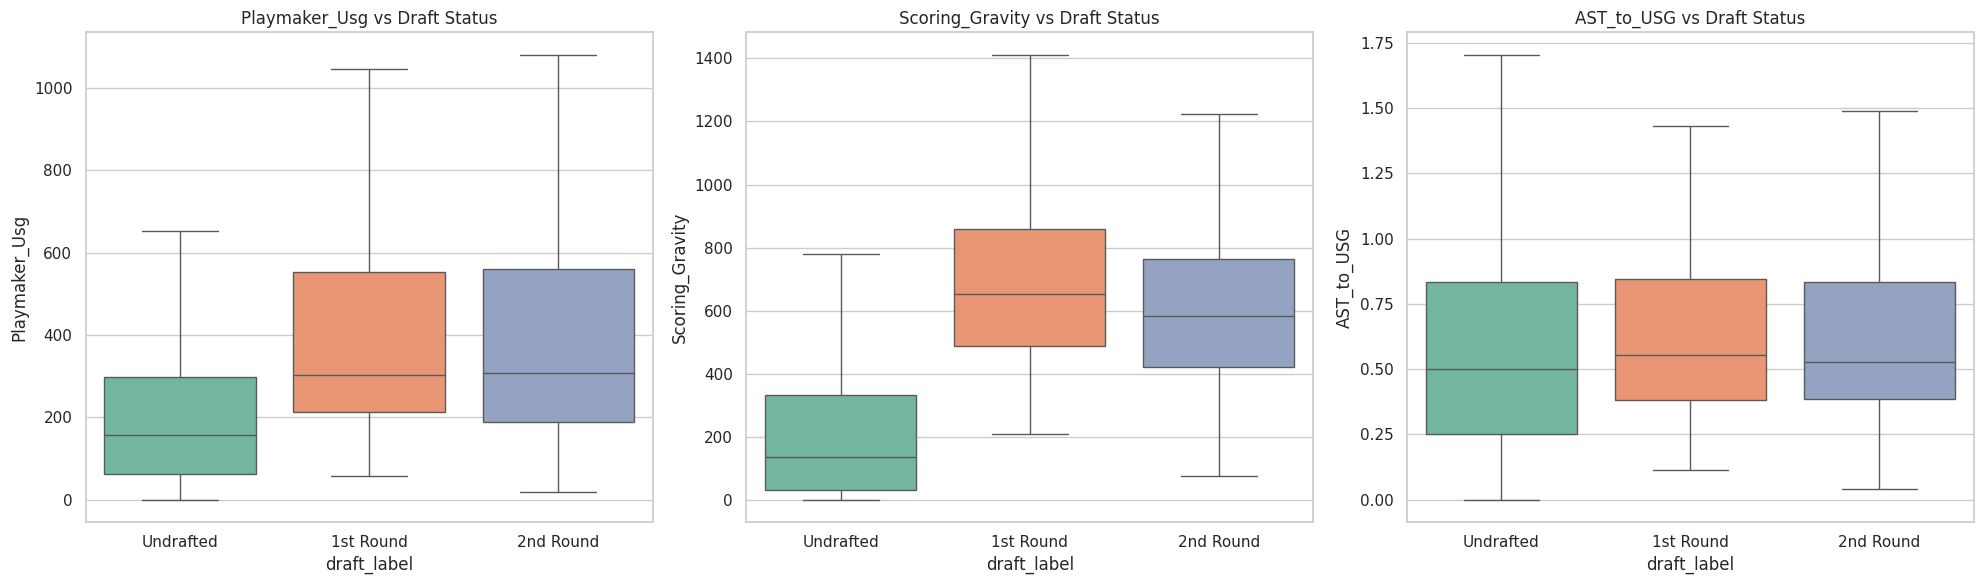

In [35]:
new_features = ['Playmaker_Usg', 'Scoring_Gravity', 'AST_to_USG']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, feature in enumerate(new_features):
    if feature in df_train.columns:
        sns.boxplot(data=df_train, x='draft_label', y=feature,
                    ax=axes[i], showfliers=False, palette='Set2',
                    order=['Undrafted', '1st Round', '2nd Round'])
        axes[i].set_title(f'{feature} vs Draft Status')
    else:
        axes[i].set_title(f'{feature} (Not Found)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10722/2385716793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Elite_Recruit', y='draft_status', ax=axes[0], palette='Blues')
/tmp/ipykernel_10722/2385716793.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='Freshman_Star', y='draft_status', ax=axes[1], palette='Reds')


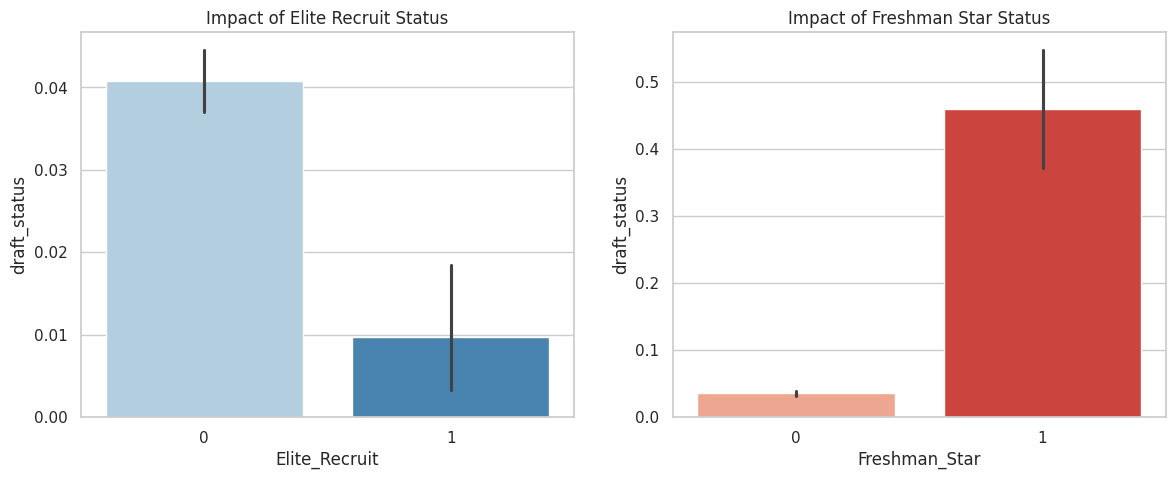

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_train, x='Elite_Recruit', y='draft_status', ax=axes[0], palette='Blues')
axes[0].set_title('Impact of Elite Recruit Status')
sns.barplot(data=df_train, x='Freshman_Star', y='draft_status', ax=axes[1], palette='Reds')
axes[1].set_title('Impact of Freshman Star Status')
plt.show()

# BPM & Points

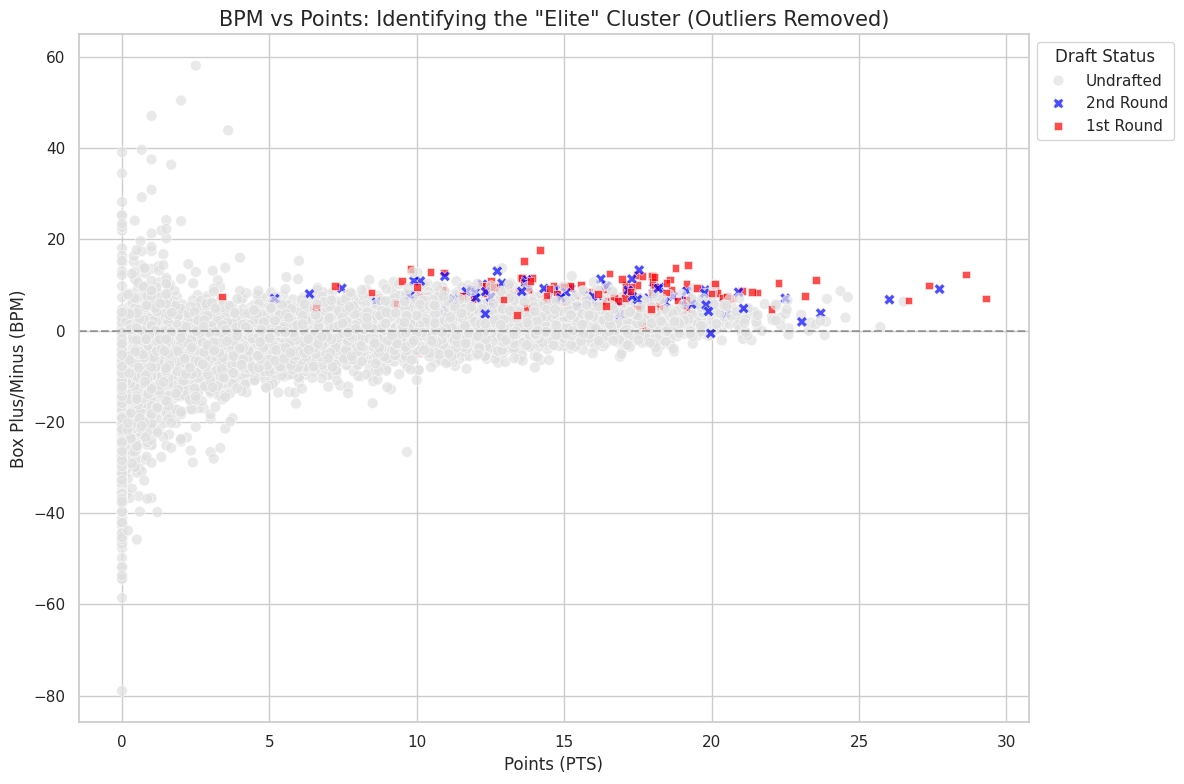

In [37]:
df_plot = df_train[df_train['bpm'] < 60].sample(min(10000, len(df_train)))

custom_palette = {
    'Undrafted': '#E0E0E0',
    '1st Round': '#FF0000',
    '2nd Round': '#0000FF'
}

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_plot,
    x='pts',
    y='bpm',
    hue='draft_label',
    style='draft_label',
    palette=custom_palette,
    hue_order=['Undrafted', '2nd Round', '1st Round'],
    alpha=0.7,
    s=60,
    edgecolor='w',
    linewidth=0.5
)

plt.title('BPM vs Points: Identifying the "Elite" Cluster (Outliers Removed)', fontsize=15)
plt.xlabel('Points (PTS)', fontsize=12)
plt.ylabel('Box Plus/Minus (BPM)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend(title='Draft Status', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# Correlation Heatmap

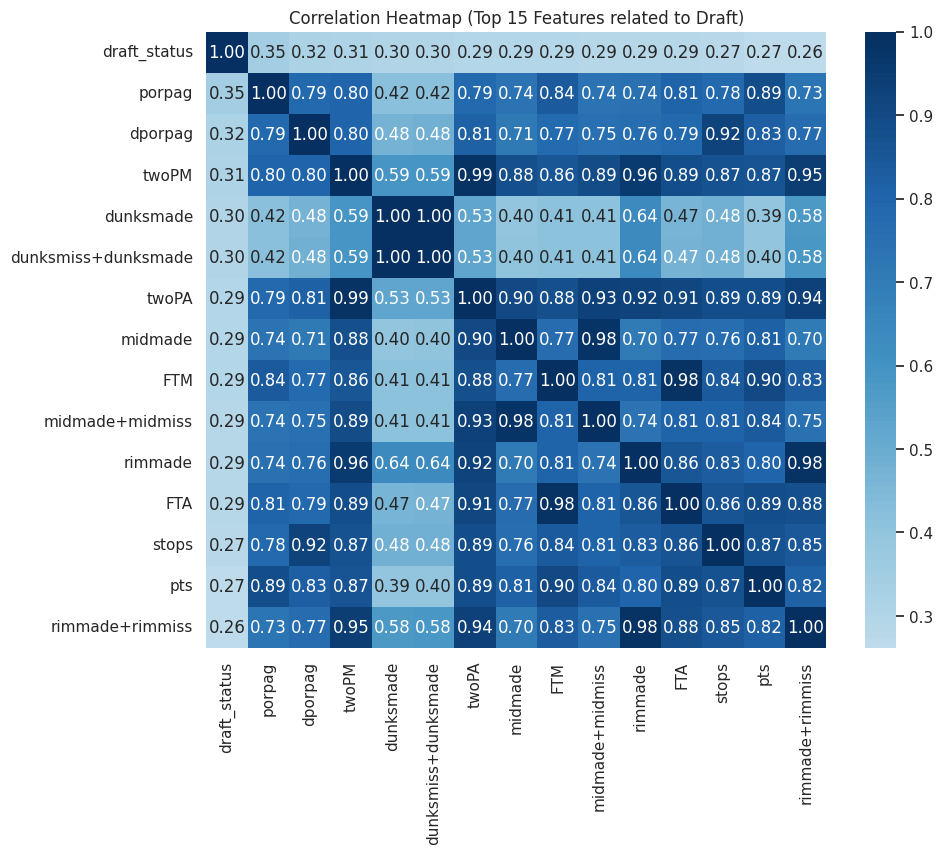

In [38]:

numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

drop_cols = ['pid', 'year', 'draft_status']
features = [c for c in numeric_cols if c not in drop_cols]


top_corr = df_train[numeric_cols].corr()['draft_status'].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.heatmap(df_train[top_corr.index].corr(), annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Correlation Heatmap (Top 15 Features related to Draft)')
plt.show()

# Data Drift: Train vs Validation

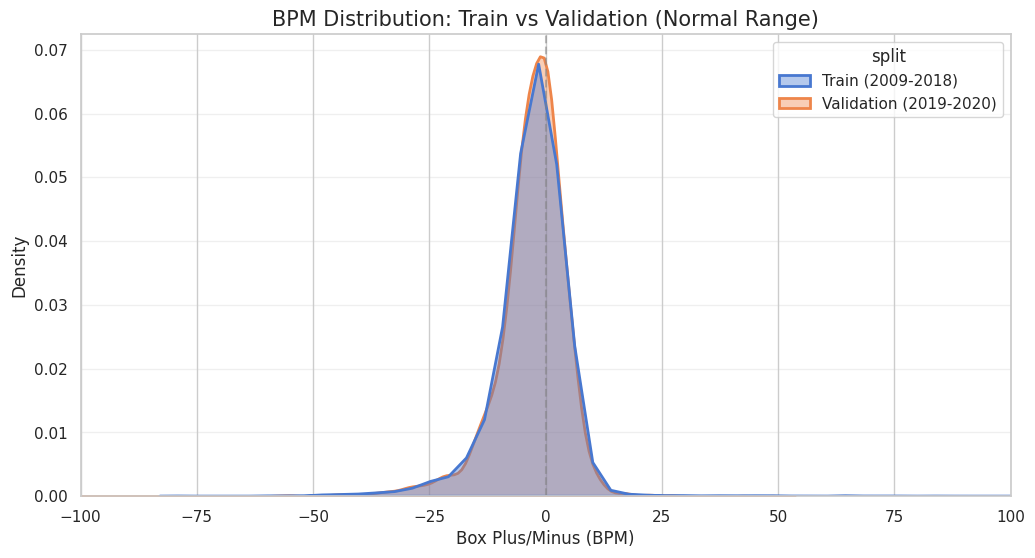

In [39]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df_combined,
    x='bpm',
    hue='split',
    fill=True,
    common_norm=False,
    palette='muted',
    linewidth=2,
    alpha=0.4
)

plt.xlim(-100, 100)


plt.title('BPM Distribution: Train vs Validation (Normal Range)', fontsize=15)
plt.xlabel('Box Plus/Minus (BPM)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.grid(axis='y', alpha=0.3)
plt.show()

# Extra Part

# Role-based Analysis

/tmp/ipykernel_10722/1554762194.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_success.index, y=role_success.values, palette='magma')


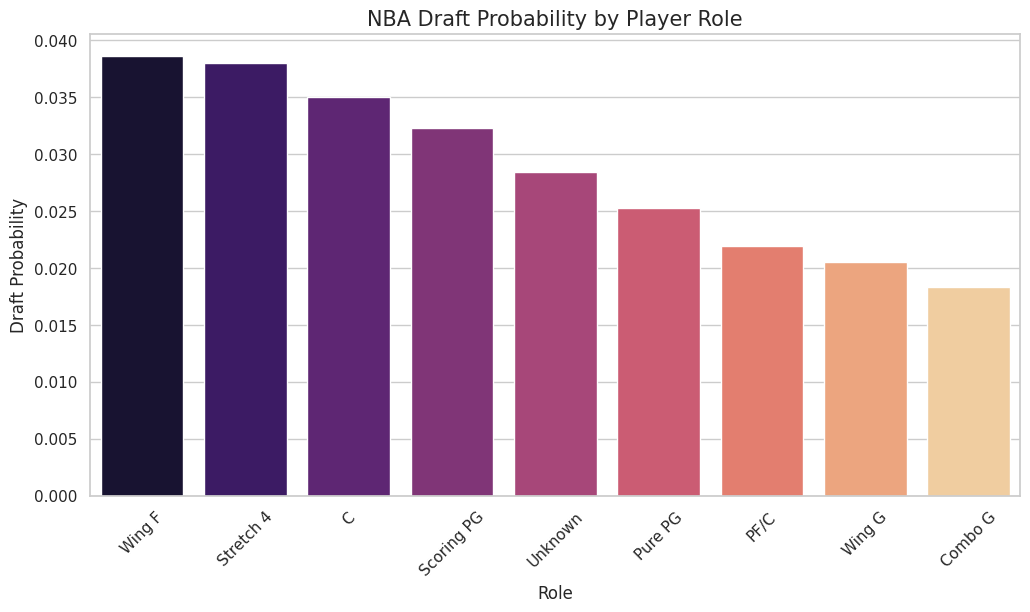

In [40]:
role_success = df_train.groupby('role')['draft_status'].apply(lambda x: (x > 0).mean()).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=role_success.index, y=role_success.values, palette='magma')
plt.xticks(rotation=45)
plt.title('NBA Draft Probability by Player Role', fontsize=15)
plt.ylabel('Draft Probability')
plt.xlabel('Role')
plt.show()

# Physical Traits

/tmp/ipykernel_10722/3982681159.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='draft_label', y='ht_inches', palette=custom_palette,


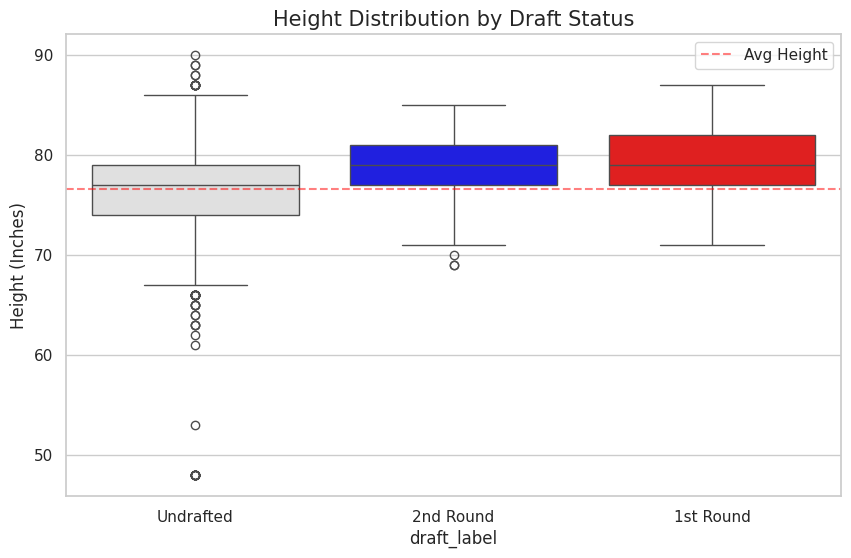

In [41]:
plt.figure(figsize=(10, 6))

custom_palette = {'Undrafted': '#E0E0E0', '1st Round': '#FF0000', '2nd Round': '#0000FF'}

sns.boxplot(data=df_train, x='draft_label', y='ht_inches', palette=custom_palette,
            order=['Undrafted', '2nd Round', '1st Round'])
plt.title('Height Distribution by Draft Status', fontsize=15)
plt.ylabel('Height (Inches)')
plt.axhline(df_train['ht_inches'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Height')
plt.legend()
plt.show()

# Efficiency vs. Volume

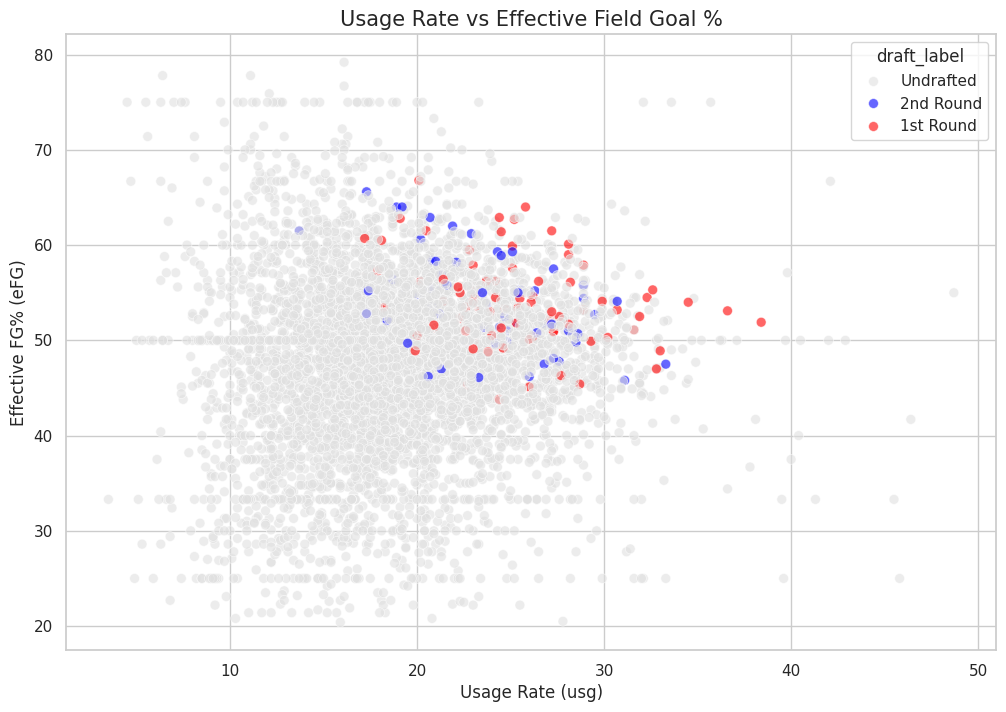

In [42]:
plt.figure(figsize=(12, 8))

df_eff = df_train[(df_train['eFG'] > 20) & (df_train['eFG'] < 80)].sample(5000)

sns.scatterplot(
    data=df_eff, x='usg', y='eFG', hue='draft_label',
    palette=custom_palette, alpha=0.6, s=50,
    hue_order=['Undrafted', '2nd Round', '1st Round']
)
plt.title('Usage Rate vs Effective Field Goal %', fontsize=15)
plt.xlabel('Usage Rate (usg)')
plt.ylabel('Effective FG% (eFG)')
plt.show()

# Conference Power

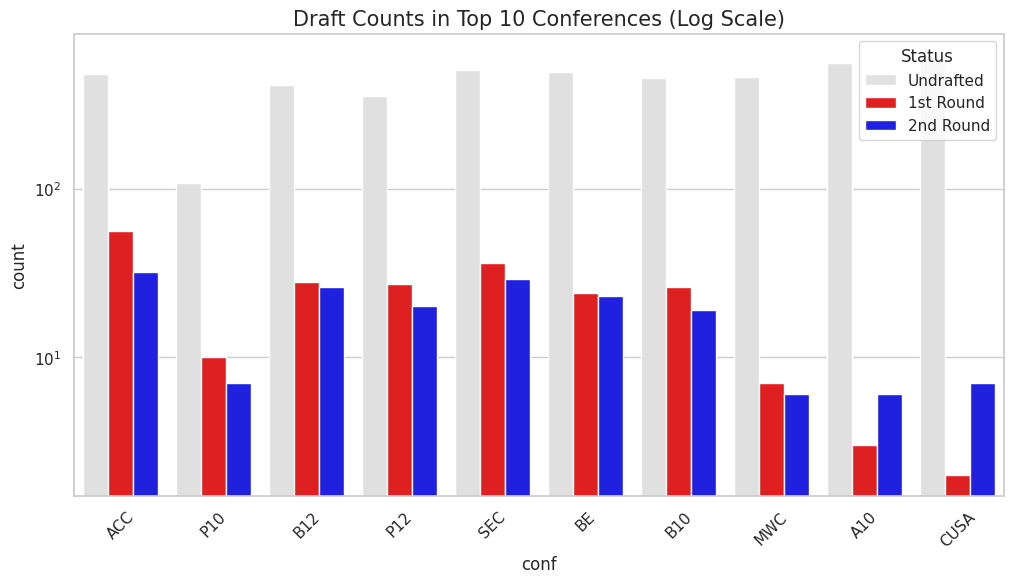

In [43]:
top_confs = df_train[df_train['draft_status'] > 0]['conf'].value_counts().head(10).index
df_top_conf = df_train[df_train['conf'].isin(top_confs)]

conf_order = df_top_conf.groupby('conf')['draft_status'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_conf, x='conf', hue='draft_label', order=conf_order, palette=custom_palette)
plt.yscale('log')
plt.title('Draft Counts in Top 10 Conferences (Log Scale)', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Status', loc='upper right')
plt.show()